## Mission 4: Predicting House Price with Multiple Linear Regression

Introduction
In this mission, you will be working with a real estate dataset to perform Exploratory Data Analysis (EDA) and create a Multiple Linear Regression (MLR) model to predict the Price of a house based on various features such as Square Feet, Number of Bedrooms, Number of Bathrooms, and other factors.

The dataset includes the following columns:

**Square_Feet:** The total area of the house in square feet.

**Num_Bedrooms:** The number of bedrooms in the house.

**Num_Bathrooms:** The number of bathrooms in the house.

**Num_Floors:** The number of floors in the house.

**Garage_Size:** The size of the garage.

**Location_Score:** A score representing the desirability of the location.

**Distance_to_Center:** The distance (in km) to the city center.

**Price:** The price of the house (target variable).


## Step 1: Loading and Understanding the Data

Start by loading the dataset into a Pandas DataFrame. Inspect the first few rows of the dataset and understand its structure.

Tasks:

Task 1.1. The data is stored in Azure Blob Storage. To connect to Azure Blob Storage, we will use a connection string that contains authentication details such as the account name and account key. See the credentials below.


Task 1.2. Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage. Name the dataframe as df_house_price

Task 1.3. Display the first few rows.

Task 1.4. Check the data types and null values.

In [1]:
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

#### **Task 1.1 to 1.3**

In [2]:
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure Blob Storage connection string
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=cWgxWhPELQdrW0sIgA/eXM8/k9+xdaELukN8sg5imfhm4wVIJQFmypEph/Ppy500v41mYT+iCBbC+AStsfHbAQ==;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

# Create a BlobServiceClient using the connection string
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the container client using the container name
container_client = blob_service_client.get_container_client(container_name)

# Get the blob client for the specific file
blob_client = container_client.get_blob_client(blob_name)

# Download the blob as a string
blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

# Convert the CSV string to Panda DataFrame and rename DataFrame as df_house_price
df_house_price = pd.read_csv(StringIO(csv_content))

# Display the first few rows of the dataframe
display(df_house_price.head())



#### **Task 1.4**

In [3]:
# Check datatypes in the df_house_price Dataframe
datatypes = df_house_price.dtypes
print(datatypes)

Square_Feet           float64
Num_Bedrooms            int64
Num_Bathrooms           int64
Num_Floors              int64
Garage_Size             int64
Location_Score        float64
Distance_to_Center    float64
Price                 float64
dtype: object


In [4]:
# Check null values in the df_house_price Dataframe
missing_values = df_house_price.isnull()

# Display only rows with null values
rows_with_nulls = df_house_price[missing_values.any(axis=1)]

# Display the rows with null values
display(rows_with_nulls)


## Step 2: Exploratory Data Analysis (EDA)

In this step, you will perform some basic EDA to understand the relationships between the features and the target variable (Price). This includes visualising the data, checking for correlations, and identifying patterns.

Tasks:

Task 2.1. Check summary statistics for the dataset.

Task 2.2. Visualise the relationship between Square Feet and Price using a scatter plot.

Task 2.3.  Visualise the distribution of the Price variable using a histogram.

Task 2.4.  Compute and visualize the correlation matrix between the features.

#### **Task 2.1**

In [5]:
# Use decribe() to check summary statistics for all columns in the dataset
summary_statistics = df_house_price.describe()
print(summary_statistics)


       Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Garage_Size  \
count   500.000000    500.000000     500.000000  500.000000   500.000000   
mean    174.640428      2.958000       1.976000    1.964000    30.174000   
std      74.672102      1.440968       0.820225    0.802491    11.582575   
min      51.265396      1.000000       1.000000    1.000000    10.000000   
25%     110.319923      2.000000       1.000000    1.000000    20.000000   
50%     178.290937      3.000000       2.000000    2.000000    30.000000   
75%     239.031220      4.000000       3.000000    3.000000    41.000000   
max     298.241199      5.000000       3.000000    3.000000    49.000000   

       Location_Score  Distance_to_Center          Price  
count      500.000000          500.000000     500.000000  
mean         5.164410           10.469641  582209.629531  
std          2.853489            5.588197  122273.390347  
min          0.004428            0.062818  276892.470100  
25%          2.76065

In [6]:
##Importing seaborn matplotlib
!pip install seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.4 MB/s eta 0:00:00ta 0:00:01


#### **Task 2.2**

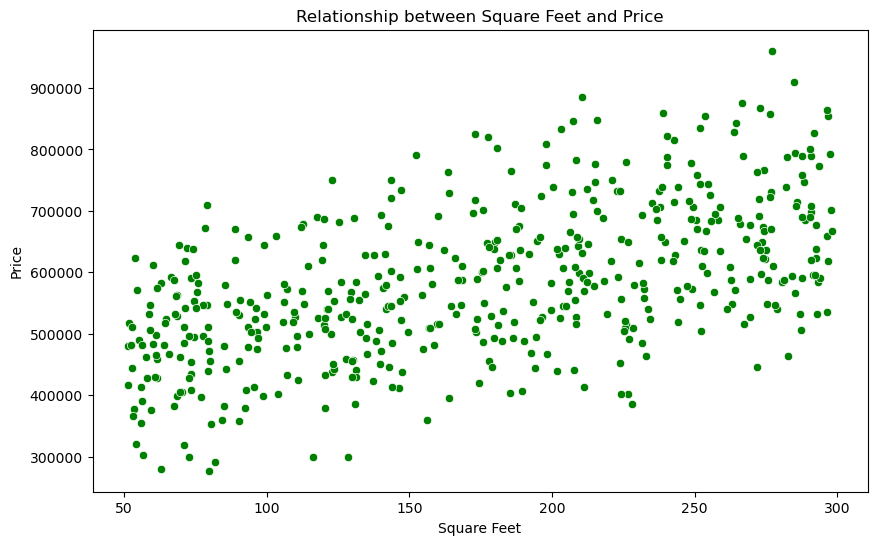

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns 

# Create scatter plot to visualise relationship between Square Feet and Price
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Square_Feet", y="Price", data=df_house_price, color="green")
plt.title("Relationship between Square Feet and Price")
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.show()

#### **Task 2.3**

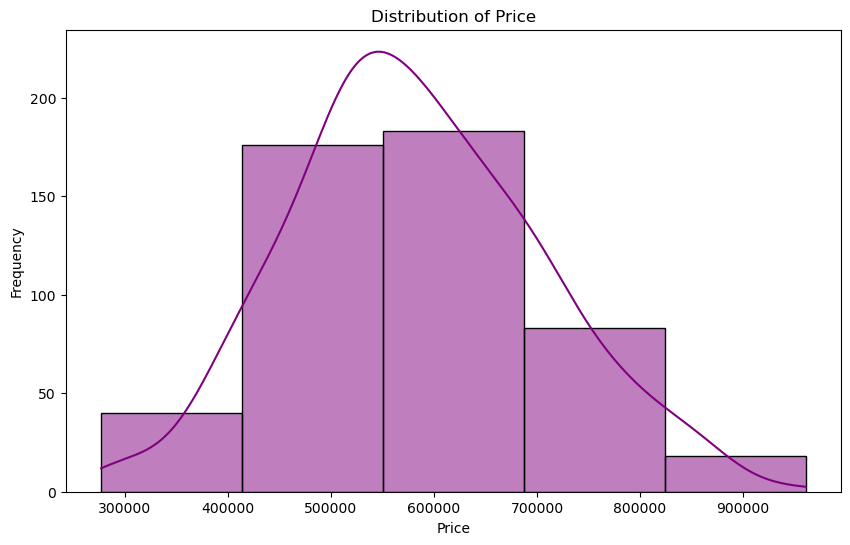

In [8]:
# Create histogram to visualise the distribution of Price
plt.figure(figsize=(10, 6))
sns.histplot(df_house_price["Price"], bins=5, color="purple", kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

#### **Task 2.4**

                    Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  \
Square_Feet            1.000000     -0.049918      -0.001667    0.056873   
Num_Bedrooms          -0.049918      1.000000      -0.056808    0.009088   
Num_Bathrooms         -0.001667     -0.056808       1.000000   -0.040895   
Num_Floors             0.056873      0.009088      -0.040895    1.000000   
Garage_Size           -0.051598     -0.065481       0.055707   -0.082763   
Location_Score        -0.035270     -0.000357      -0.013855    0.019928   
Distance_to_Center     0.093080      0.040511      -0.082571    0.035164   
Price                  0.558604      0.563973       0.156689    0.177435   

                    Garage_Size  Location_Score  Distance_to_Center     Price  
Square_Feet           -0.051598       -0.035270            0.093080  0.558604  
Num_Bedrooms          -0.065481       -0.000357            0.040511  0.563973  
Num_Bathrooms          0.055707       -0.013855           -0.082571  0.1566

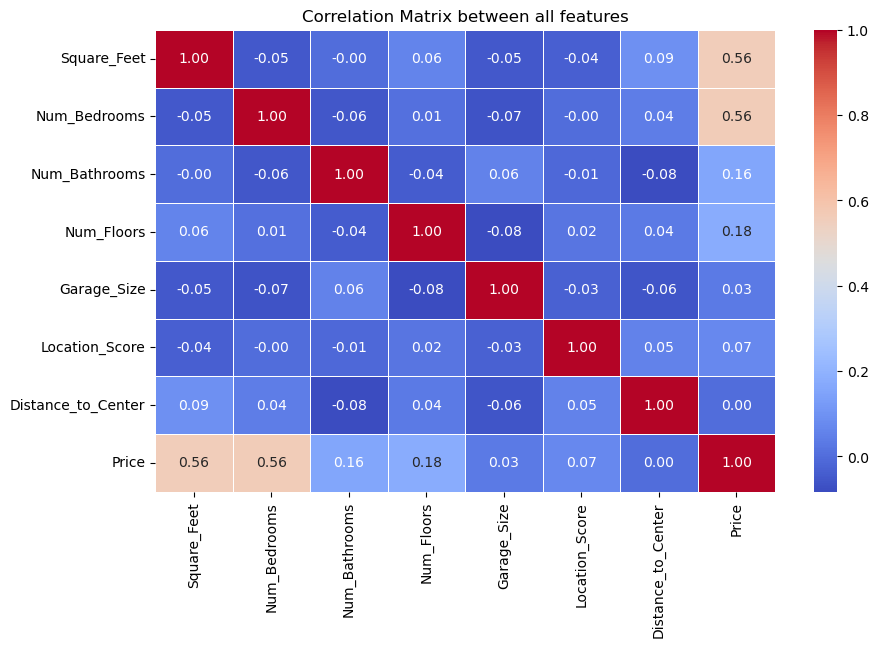

In [9]:
# Calculate correlation between all features ("Square_Feet", "Num_Bedrooms", "Num_Bathrooms", "Num_Floors", "Garage_Size", "Location_Score", "Distance_to_Center", "Price")
correlation = df_house_price.corr()

# Display the correlation matrix
print(correlation)

# Create heatmap to visualise the correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix between all features")
plt.show()

## Step 3: Creating a Multiple Linear Regression (MLR) Model

In this step, we will use Multiple Linear Regression to predict the Price of the house based on the features. We will split the data into a training set and a testing set, fit the model, and evaluate its performance.

Task 3.1: Split the Data into Features and Target
Split the dataset into features (X) and target variable (y).

Task 3.2: Split the Data into Training and Testing Sets
Split the data into training (80%) and testing (20%) sets.

Task 3.3: Train the Multiple Linear Regression Model
Train the Multiple Linear Regression (MLR) model using the training data.

Task 3.4: Visualise the Predicted vs Actual Prices
Create a scatter plot comparing the actual prices and predicted prices for the test set.

Task 3.5: Evaluate the Model
Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

#### **Task 3.1**

In [10]:
# Split all features except Price into features (X) and Price into target (y)
X = df_house_price[["Square_Feet", "Num_Bedrooms", "Num_Bathrooms", "Num_Floors", "Garage_Size", "Location_Score", "Distance_to_Center"]]
y = df_house_price["Price"]

#### **Task 3.2**

In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the training set and the test set
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

Training Data: (400, 7), Testing Data: (100, 7)


#### **Task 3.3**

In [12]:
from sklearn.linear_model import LinearRegression

# Create and fit the Multiple Linear Regression Model on the training data
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Make predictions on the test data
y_pred_lr = model_lr.predict(X_test)

🏃 View run lemon_parang_tpmnr6pp at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/b8e52a49-29a6-44b9-ba31-ebabb9b70c38/#/experiments/bec1cd12-5be2-481f-9278-902c13d87a5d/runs/d9923878-fd0c-430a-b998-2c2bdb93ecf0
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/b8e52a49-29a6-44b9-ba31-ebabb9b70c38/#/experiments/bec1cd12-5be2-481f-9278-902c13d87a5d


#### **Task 3.4**

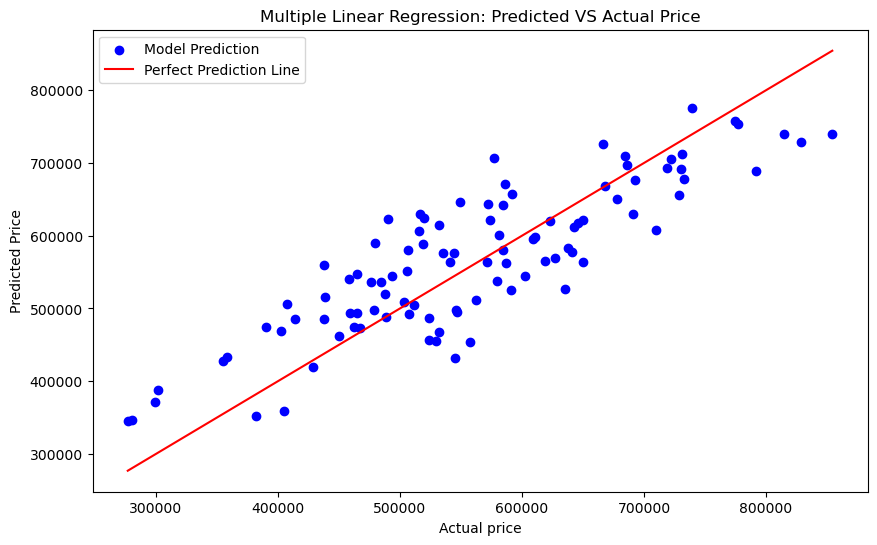

In [13]:
# Visualise the predicted vs actual price by creating a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, color="blue", label="Model Prediction")

# Define the boundaries for the Perfect Prediction Line
boundaries = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]

# Plot the Perfect Prediction Line based on the tested and predicted data
plt.plot(boundaries, boundaries, color="red", label="Perfect Prediction Line")
plt.title("Multiple Linear Regression: Predicted VS Actual Price")
plt.xlabel("Actual price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

#### **Task 3.5**

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Calculate RMSE for the MLR model
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

# Calculate relative RMSE by using the RMSE (Relative RMSE = RMSE / mean price * 100)
relative_err = rmse_lr / df_house_price["Price"].mean() * 100

print(f"RMSE for MLR model: {rmse_lr}, relative error: {relative_err}%")

RMSE for MLR model: 63952.37599755184, relative error: 10.984424295608223%


Based on the RMSE and the relative error value, the multiple linear regression model is making moderately accurate predictions, which is considered as acceptable but might have room for improvement. On average, the model's predicted prices deviated from the actual prices by around $63952.38. 

## Step 4: Compare with Random Forest Regressor

Task 4.1: Train a Random Forest Model
Train a Random Forest Regressor model and evaluate its performance.

Task 4.2: Visualise Actual vs Predicted Prices for Random Forest
Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

Task 4.3: Model Comparison
Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

# Task 4.1

In [15]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Create the Random Forest Regressor model
model_rf = RandomForestRegressor(n_estimators=2000,random_state=42)

# Train the Random Forest model using the training data
model_rf.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = model_rf.predict(X_test)

# Calculate RMSE for the Random Forest model
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"RMSE for Random Forest model: {rmse_rf}")


🏃 View run clever_star_m8qznbx6 at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/b8e52a49-29a6-44b9-ba31-ebabb9b70c38/#/experiments/bec1cd12-5be2-481f-9278-902c13d87a5d/runs/638ae744-2d1f-47d2-95a9-73a581776d75
🧪 View experiment at: https://2d0fc43f898c4b4fa153ed44d311104c.pbidedicated.windows.net/webapi/capacities/2d0fc43f-898c-4b4f-a153-ed44d311104c/workloads/ML/ML/Automatic/workspaceid/b8e52a49-29a6-44b9-ba31-ebabb9b70c38/#/experiments/bec1cd12-5be2-481f-9278-902c13d87a5d


RMSE for Random Forest model: 71215.87827390428


# Task 4.2

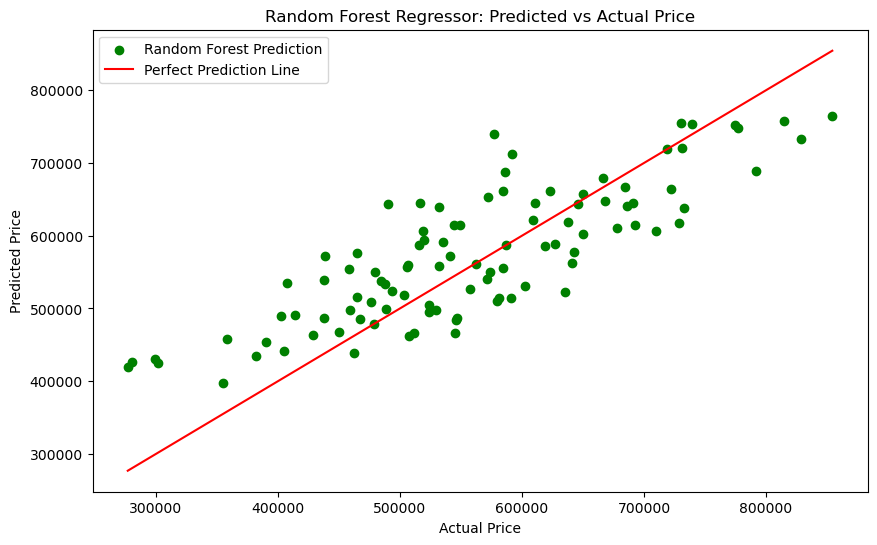

In [16]:
# Visualise the actual vs predicted prices for the Random Forest model
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred_rf,color="green",label="Random Forest Prediction")

# Define the boundaries for the Perfect Prediction Line
boundaries = [min(y_test.min(),y_pred_rf.min()),max(y_test.max(),y_pred_rf.max())]

# Plot the Perfect Prediction Line
plt.plot(boundaries,boundaries,color="red",label="Perfect Prediction Line")

plt.title("Random Forest Regressor: Predicted vs Actual Price")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

# Task 4.3

In [17]:
# Compare RMSE values of Multiple Linear Regression and Random Forest
print(f"RMSE for Multiple Linear Regression model: {rmse_lr}")
print(f"RMSE for Random Forest model: {rmse_rf}")

# Check which model performs better
if rmse_rf < rmse_lr:
    print("The Random Forest model performs better because it has a lower RMSE.")
elif rmse_lr < rmse_rf:
    print("The Multiple Linear Regression model performs better because it has a lower RMSE.")
else:
    print("Both models have the same RMSE, so they performed equally.")

RMSE for Multiple Linear Regression model: 63952.37599755184
RMSE for Random Forest model: 71215.87827390428
The Multiple Linear Regression model performs better because it has a lower RMSE.


## Step 5: Conclusion and Insights

Task 5.1: Insights and Recommendations

Based on the RMSE and visualisations, summarise which model performs better and why.

Discuss any improvements that could be made to both models.

Based on these results, the Multiple Linear Regression model performed better because it had the lower RMSE. This means the predictions from the Multiple Linear Regression model were closer to the actual house prices compared with the Random Forest model.
The scatter plots also support this result. In both graphs, the predicted prices followed the general direction of the perfect prediction line. This shows that both models were able to understand the general pattern in house prices. However, because the Multiple Linear Regression model had a lower RMSE, it was the more accurate model overall.

This result suggests that the relationship between the house features and the price may be mostly linear, as features such as square feet, number of bedrooms, bathrooms, location score, and other values change, the house price changes in a fairly consistent way. Because of this, the simpler Multiple Linear Regression model worked better than the more complex Random Forest model.

To improve the models, more useful house information could be added, such as the age of the property, land size, suburb, property type, condition of the house, and nearby facilities. The dataset could also be checked for outliers. Very high or very low house prices can affect the model and make predictions less accurate. Removing or managing these unusual values may improve the results.

For the Multiple Linear Regression model, it would be useful to check if the data follows a linear pattern and if the features are not too strongly related to each other. For the Random Forest model, the results may improve by testing different settings, such as the number of trees and the depth of each tree.

Cross-validation could also be used to make the results more reliable, instead of using only one training and testing split.

Overall, the Multiple Linear Regression model is the preferred model for this dataset because it had the lowest RMSE and made more accurate predictions than the Random Forest Regressor.


Hi team,

Well done on the code overall. However, I can see that you are not using Markdown cells to provide explanations of your code, methodology, and insights.

I strongly suggest that you add notes throughout the notebook explaining:

* The approach you are taking
* Why you are using certain functions or techniques
* What the output or analysis means

Additionally, after every chart, table, or major output, you should include a short insight section explaining the key findings and business interpretation of the results.

Remember that in data analytics, storytelling and interpretation are just as important as the code itself. The reader should be able to clearly understand your analytical process and conclusions by following both your code and your explanations.

Regards,
Jose
